In [1]:
import os
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"

processed_paths_dict = { 
    "beta": os.path.join(PROCESSED_DIR, "beta.parquet"),
    "mean_volatility": os.path.join(PROCESSED_DIR, "mean_volatility.parquet"),
    "microstructure": os.path.join(PROCESSED_DIR, "microstructure.parquet"),
    "momentum": os.path.join(PROCESSED_DIR, "momentum.parquet"),
    "momentum_liquidity": os.path.join(PROCESSED_DIR, "momentum_liquidity.parquet"),
    "pvo": os.path.join(PROCESSED_DIR, "pvo.parquet"), 
    "reversal": os.path.join(PROCESSED_DIR, "reversal.parquet"),
    "reversal_illiquidity": os.path.join(PROCESSED_DIR, "reversal_illiquidity.parquet")
}

In [2]:
BASE_DIR

WindowsPath('c:/Users/Gordon Li/Desktop/systematic_project')

In [3]:
import numpy as np 
import pandas as pd

from scripts.research.ic import IC
from scripts.research.quintile import Quintile
from scripts.research.plots import (
    plot_ic_timeseries, 
    plot_ic_summary_bar, 
    plot_quintiles
)
from scripts.research.targets import ForwardReturns

## Forward Returns

In [4]:
returns_df = ForwardReturns([5, 10, 21]).run_data()

factors_df_dict = {}
for key, path in processed_paths_dict.items(): 
    factors_df_dict[key] = pd.read_parquet(path)

In [5]:
Quintile(returns_df, factors_df_dict["momentum"]).run_data()

({'momentum_252_12':            Date  quintile  future_return_5d
  0    2023-07-13         1          0.002166
  1    2023-07-13         2          0.012513
  2    2023-07-13         3          0.006387
  3    2023-07-13         4          0.003198
  4    2023-07-13         5          0.018369
  ...         ...       ...               ...
  3665 2026-06-04         1          0.062486
  3666 2026-06-04         2          0.040832
  3667 2026-06-04         3          0.028729
  3668 2026-06-04         4         -0.007888
  3669 2026-06-04         5         -0.055824
  
  [3670 rows x 3 columns],
  'id_252_12':            Date  quintile  future_return_5d
  0    2023-07-13         1          0.025935
  1    2023-07-13         2          0.002381
  2    2023-07-13         3          0.005177
  3    2023-07-13         4          0.001459
  4    2023-07-13         5          0.007339
  ...         ...       ...               ...
  3665 2026-06-04         1          0.041998
  3666 2026-06-04 

## Information Coefficient

In [6]:
ic_dict, ic_results_dict = dict(), dict()
for factor, df in factors_df_dict.items(): 
    ic_dict[factor], ic_results_dict[factor] = IC(returns_df, factors_df_dict[factor]).run_data()

### Beta

In [7]:
beta_ic_dict, beta_results_df = ic_dict["beta"], ic_results_dict["beta"]

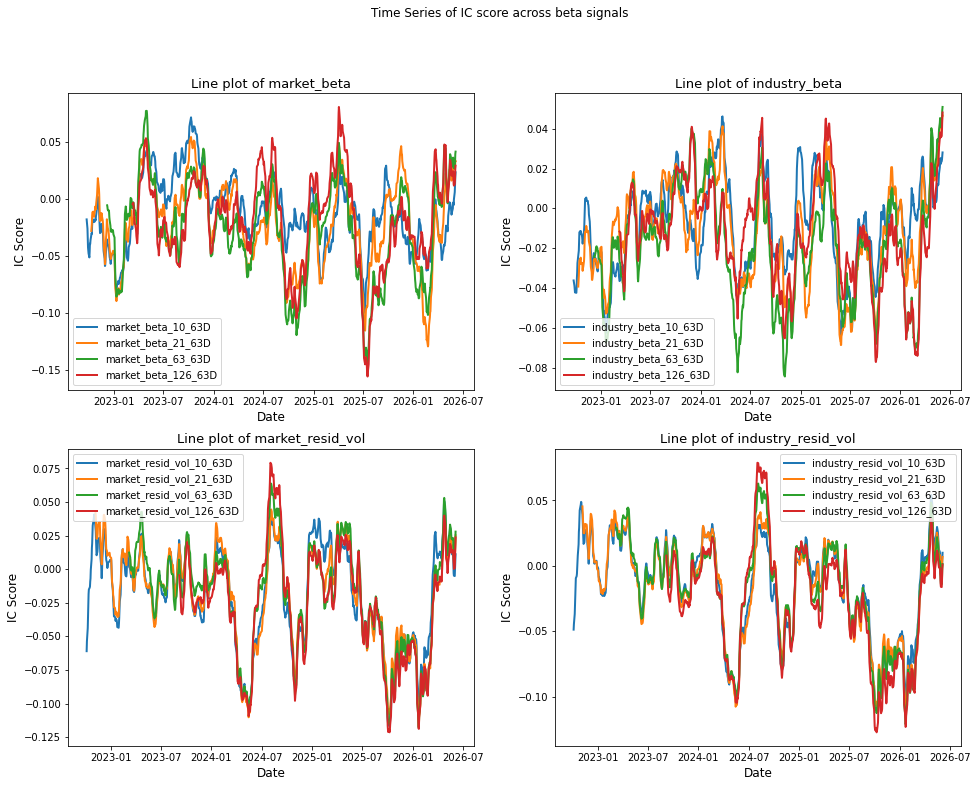

In [8]:
plot_ic_timeseries(beta_ic_dict, "beta")

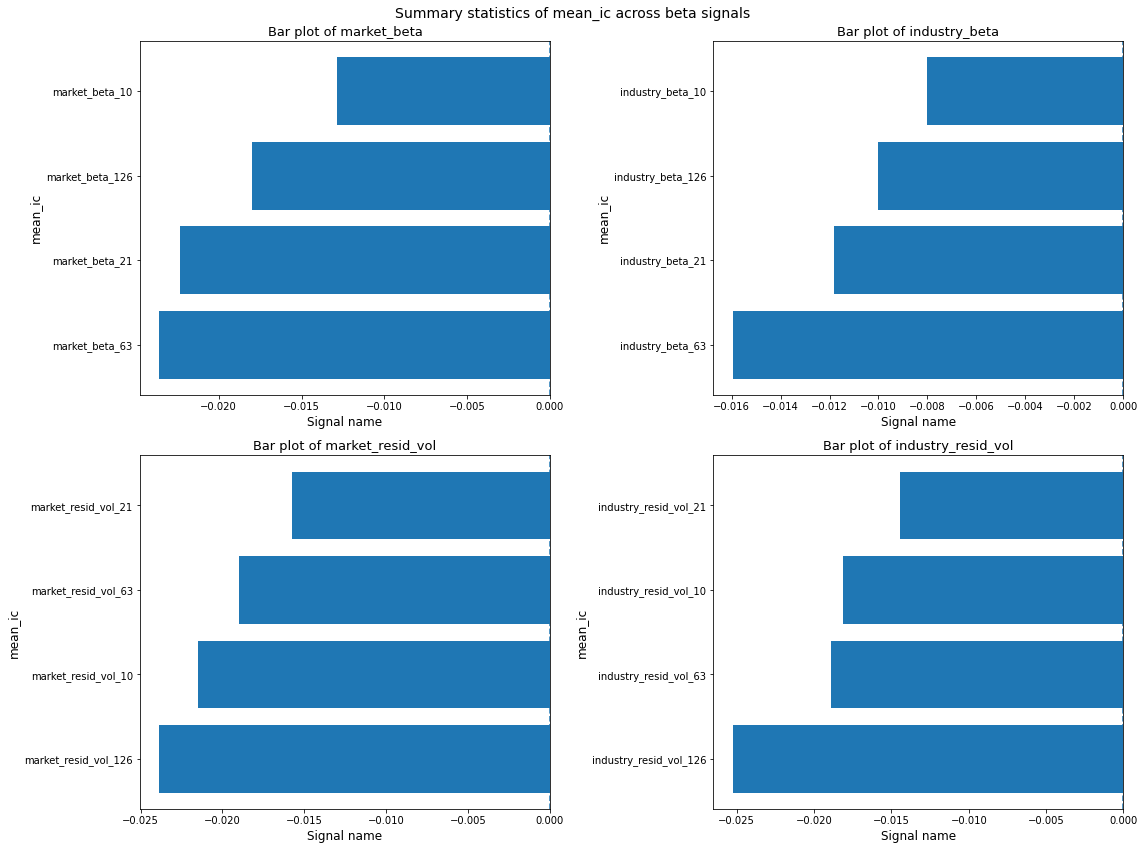

In [9]:
plot_ic_summary_bar(beta_ic_dict, beta_results_df, "beta", metric="mean_ic")

### Mean Volatility

In [10]:
mv_ic_dict, mv_results_df = ic_dict["mean_volatility"], ic_results_dict["mean_volatility"]

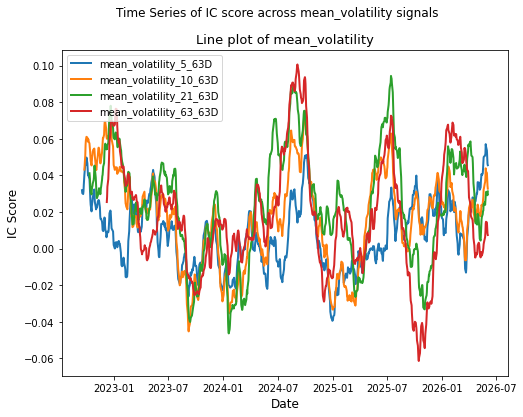

In [11]:
plot_ic_timeseries(mv_ic_dict, "mean_volatility")

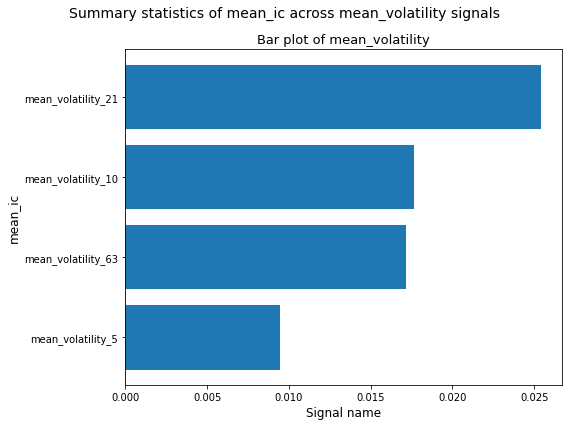

In [12]:
plot_ic_summary_bar(mv_ic_dict, mv_results_df, "mean_volatility", metric="mean_ic")

### Microstructure

In [13]:
microstructure_ic_dict, microstructure_results_df = ic_dict["microstructure"], ic_results_dict["microstructure"]

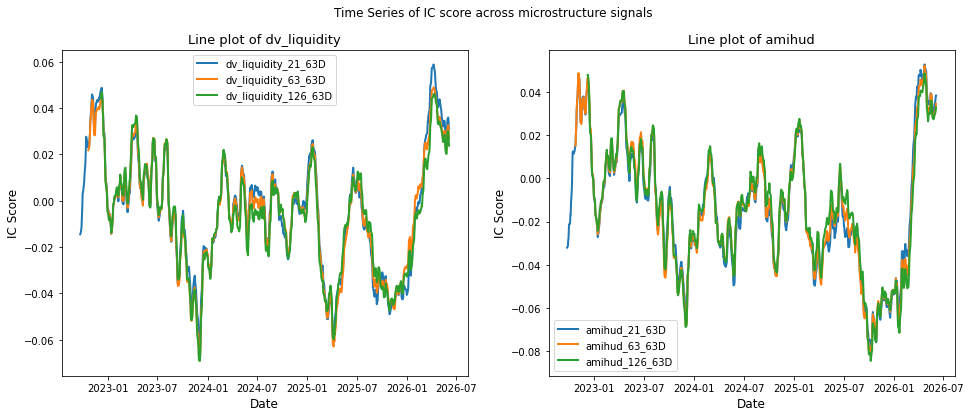

In [14]:
plot_ic_timeseries(microstructure_ic_dict, "microstructure")

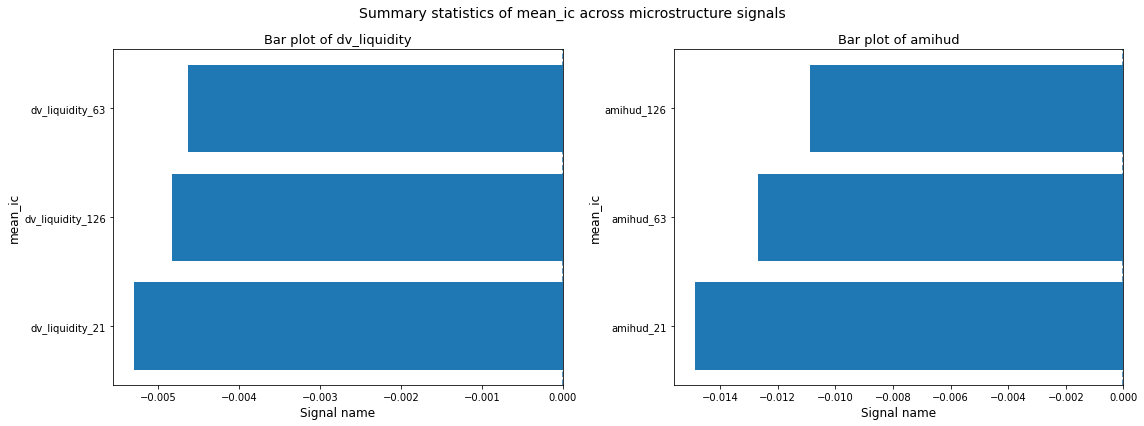

In [15]:
plot_ic_summary_bar(microstructure_ic_dict, microstructure_results_df, "microstructure", metric="mean_ic")

### Momentum

In [16]:
momentum_ic_dict, momentum_results_df = ic_dict["momentum"], ic_results_dict["momentum"]

In [22]:
momentum_results_df

,momentum_252_12,id_252_12
mean_ic,0.044546,0.017138
std_ic,0.173242,0.116036
ic_ir,0.257132,0.147695
positive_ic_rate,0.637602,0.554496
n_periods,734.000000,734.000000


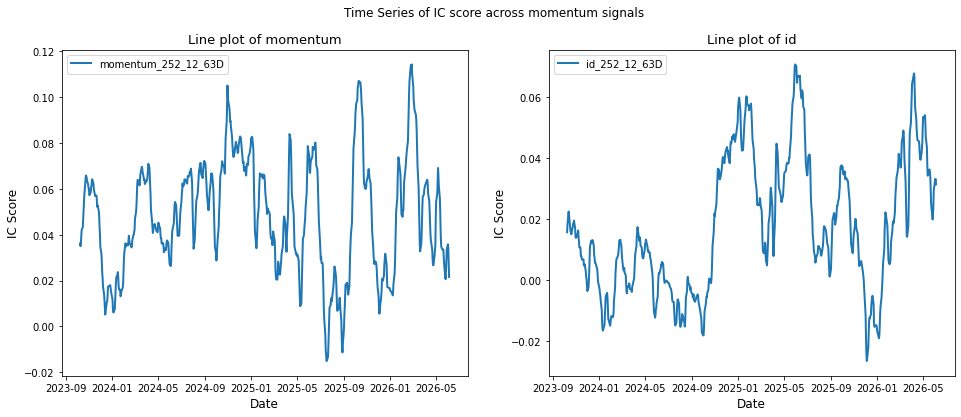

In [17]:
plot_ic_timeseries(momentum_ic_dict, "momentum")

In [18]:
momentum_quintile_dict, momentum_summary_quintile_df = Quintile(returns_df, factors_df_dict["momentum"]).run_data()

In [19]:
momentum_quintile_dict

{'momentum_252_12':            Date  quintile  future_return_5d
 0    2023-07-13         1          0.002166
 1    2023-07-13         2          0.012513
 2    2023-07-13         3          0.006387
 3    2023-07-13         4          0.003198
 4    2023-07-13         5          0.018369
 ...         ...       ...               ...
 3665 2026-06-04         1          0.062486
 3666 2026-06-04         2          0.040832
 3667 2026-06-04         3          0.028729
 3668 2026-06-04         4         -0.007888
 3669 2026-06-04         5         -0.055824
 
 [3670 rows x 3 columns],
 'id_252_12':            Date  quintile  future_return_5d
 0    2023-07-13         1          0.025935
 1    2023-07-13         2          0.002381
 2    2023-07-13         3          0.005177
 3    2023-07-13         4          0.001459
 4    2023-07-13         5          0.007339
 ...         ...       ...               ...
 3665 2026-06-04         1          0.041998
 3666 2026-06-04         2          0.01

In [20]:
momentum_summary_quintile_df

{'momentum_252_12':             factor            target quintile  mean_forward_return  \
 0  momentum_252_12  future_return_5d        1             0.002105   
 1  momentum_252_12  future_return_5d        2             0.002568   
 2  momentum_252_12  future_return_5d        3             0.002234   
 3  momentum_252_12  future_return_5d        4             0.003749   
 4  momentum_252_12  future_return_5d        5             0.008171   
 5  momentum_252_12  future_return_5d    Q5-Q1             0.006066   
 
    std_forward_return  n_periods  
 0            0.023599        734  
 1            0.015169        734  
 2            0.014787        734  
 3            0.017648        734  
 4            0.032084        734  
 5            0.028902        734  ,
 'id_252_12':       factor            target quintile  mean_forward_return  \
 0  id_252_12  future_return_5d        1             0.004813   
 1  id_252_12  future_return_5d        2             0.002855   
 2  id_252_12  future

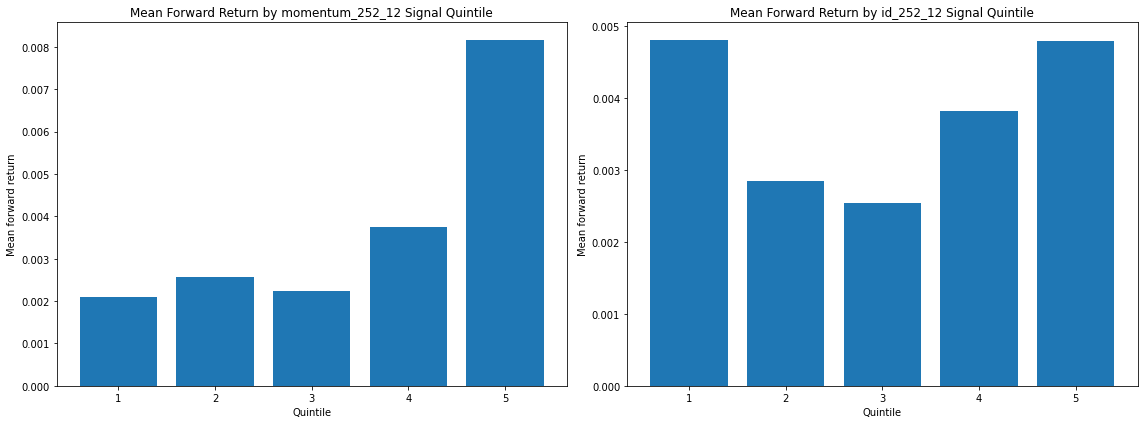

In [21]:
plot_quintiles(momentum_summary_quintile_df, "momentum")

### Reversal

In [23]:
reversal_ic_dict, reversal_results_df = ic_dict["reversal"], ic_results_dict["reversal"]

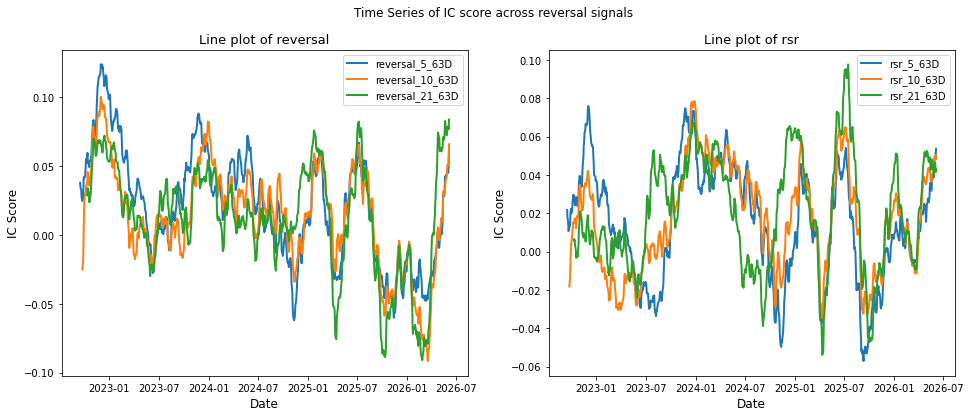

In [24]:
plot_ic_timeseries(reversal_ic_dict, "reversal")

In [25]:
reversal_quintile_dict, reversal_summary_quintile_df = Quintile(returns_df, factors_df_dict["reversal"]).run_data()

In [30]:
reversal_summary_quintile_df["rsr_5"]

,factor,target,quintile,mean_forward_return,std_forward_return,n_periods
0,rsr_5,future_return_5d,1,0.004626,0.023137,1002
1,rsr_5,future_return_5d,2,0.002881,0.017663,1002
2,rsr_5,future_return_5d,3,0.002771,0.017232,1002
3,rsr_5,future_return_5d,4,0.003547,0.018638,1002
4,rsr_5,future_return_5d,5,0.006761,0.027420,1002
5,rsr_5,future_return_5d,Q5-Q1,0.002135,0.020542,1002


### PVO

In [18]:
pvo_ic_dict, pvo_results_df = ic_dict["pvo"], ic_results_dict["pvo"]

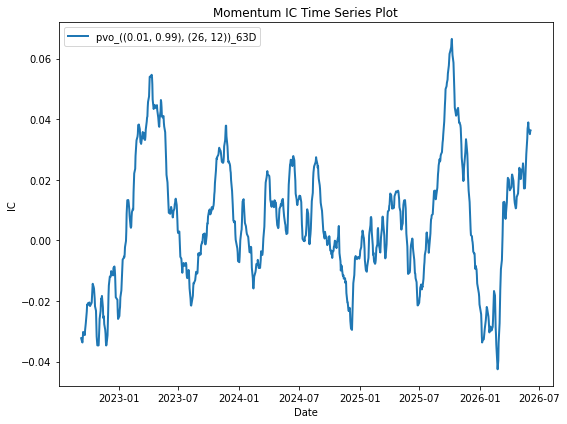

In [19]:
plot_ic_timeseries(pvo_ic_dict, title='Momentum IC Time Series Plot')

### Reversal Illiquidity

In [ ]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

In [31]:
reversal_ic_dict["reversal_10"]

{'reversal_5': {...},
 'reversal_10': {...},
 'reversal_21': {...},
 'rsr_5': {...},
 'rsr_10': {...},
 'rsr_21': {...}}

<AxesSubplot:>

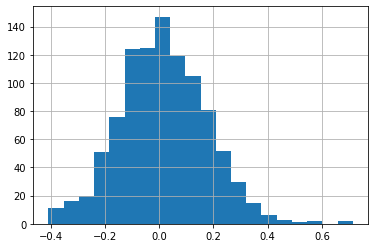

In [16]:
reversal_ic_dict["reversal_21"].hist(bins=20)

In [18]:
IC(returns_df, factors_df_dict["momentum_liquidity"]).run_data()

({'momentum_liquidity_21':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_21  future_return_5d  0.107145
  1   2023-07-14  momentum_liquidity_21  future_return_5d  0.002506
  2   2023-07-17  momentum_liquidity_21  future_return_5d -0.016175
  3   2023-07-18  momentum_liquidity_21  future_return_5d  0.011867
  4   2023-07-19  momentum_liquidity_21  future_return_5d  0.061042
  ..         ...                    ...               ...       ...
  729 2026-05-29  momentum_liquidity_21  future_return_5d -0.059243
  730 2026-06-01  momentum_liquidity_21  future_return_5d -0.145856
  731 2026-06-02  momentum_liquidity_21  future_return_5d -0.261944
  732 2026-06-03  momentum_liquidity_21  future_return_5d -0.287476
  733 2026-06-04  momentum_liquidity_21  future_return_5d -0.228393
  
  [734 rows x 4 columns],
  'momentum_liquidity_63':           Date                 factor            target        IC
  0   2023-07-13  momentum_liquidity_

In [8]:
IC(returns_df, factors_df_dict["pvo"]).run_data()

,"pvo_((0.01, 0.99), (26, 12))"
ic_ir,0.055447
mean_ic,0.005391
n_periods,1006.000000
positive_ic_rate,0.504970
std_ic,0.097222


In [9]:
IC(returns_df, factors_df_dict["reversal"]).run_data()

,reversal_5,reversal_10,reversal_21,rsr_5,rsr_10,rsr_21
mean_ic,0.023775,0.014680,0.015380,0.015893,0.016805,0.019927
std_ic,0.154832,0.159929,0.161706,0.116616,0.116223,0.119392
ic_ir,0.153553,0.091791,0.095111,0.136280,0.144597,0.166901
positive_ic_rate,0.567864,0.517553,0.530426,0.546906,0.566700,0.565923
n_periods,1002.000000,997.000000,986.000000,1002.000000,997.000000,986.000000


In [11]:
IC(returns_df, factors_df_dict["reversal_illiquidity"]).run_data()

,"reversal_illiquidity_(5, 21)","reversal_illiquidity_(5, 63)","reversal_illiquidity_(5, 126)","reversal_illiquidity_(10, 21)","reversal_illiquidity_(10, 63)","reversal_illiquidity_(10, 126)","reversal_illiquidity_(21, 21)","reversal_illiquidity_(21, 63)","reversal_illiquidity_(21, 126)"
mean_ic,0.000906,0.002136,0.004395,-0.005545,-0.003548,-0.000557,-0.002796,-0.003191,-0.001153
std_ic,0.137560,0.138776,0.138489,0.143973,0.145102,0.143113,0.142457,0.145326,0.144678
ic_ir,0.006588,0.015390,0.031733,-0.038513,-0.024449,-0.003893,-0.019629,-0.021957,-0.007972
positive_ic_rate,0.491474,0.494877,0.501059,0.484453,0.483607,0.495763,0.489858,0.495902,0.502119
n_periods,997.000000,976.000000,944.000000,997.000000,976.000000,944.000000,986.000000,976.000000,944.000000
